# ltu-ili jupyter interface
This is a tutorial for using the ltu-ili inference framework in a jupyter notebook. 

This notebook assumes you have installed the ltu-ili package from the installation instructions in [INSTALL.md](../INSTALL.md).

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import torch

import ili
from ili.dataloaders import NumpyLoader
from ili.inference import InferenceRunner
from ili.validation.metrics import PosteriorCoverage, PlotSinglePosterior

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', device)

Device: cpu


## Toy NPE
$$ X = \mathcal{N}(Y, [cY + d]^2) $$

In [18]:
# create synthetic catalog
def simulator(params):
    # create toy simulations
    c, d = 0.1, 0.01
    stdx = params[0] * c + d
    x = np.random.normal(loc=params[0], scale=stdx)
    return x


seed_sim = 12345
np.random.seed(seed_sim)
theta = np.random.rand(10_000, 1)  # 200 simulations, 1 parameter
x = np.array([simulator(t) for t in theta])[:, None]

# make a dataloader
loader = NumpyLoader(x=x, theta=theta)

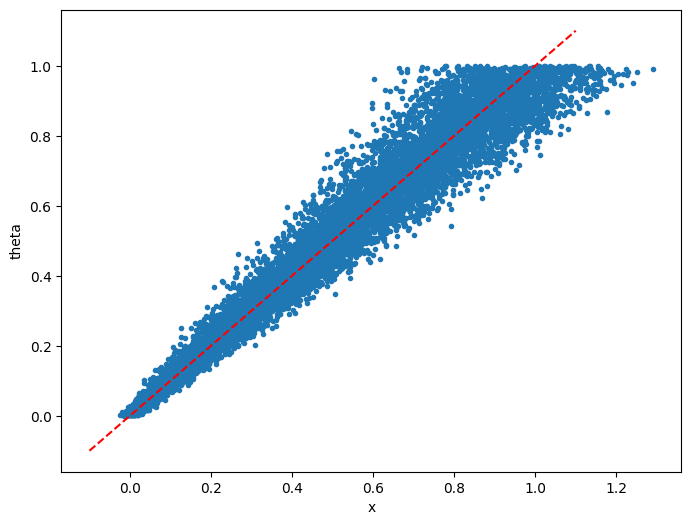

In [19]:
# plot some examples of the data
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(x, theta, '.')
ax.plot([-0.1, 1.1], [-0.1, 1.1], 'r--', label='y=x')
ax.set(xlabel='x', ylabel='theta')
plt.show()

In [20]:
# define a prior
prior = ili.utils.Uniform(low=[0], high=[1], device=device)

# instantiate your neural networks to be used as an ensemble
nets = [
    # ili.utils.load_nde_sbi(engine='NPE', model='nsf',
    #                        hidden_features=4, num_transforms=2)
    ili.utils.load_nde_sbi(engine='NPE', model='mdn',
                           hidden_features=4, num_components=1)
]

# define training arguments
train_args = {
    'training_batch_size': 128,
    'learning_rate': 1e-4
}

# initialize the trainer
runner = InferenceRunner.load(
    backend='sbi',
    engine='NPE',
    prior=prior,
    nets=nets,
    device=device,
    train_args=train_args,
    proposal=None,
    out_dir=None
)

In [21]:
# train the model
posterior_ensemble, summaries = runner(loader=loader)

INFO:root:MODEL INFERENCE CLASS: NPE
INFO:root:Training model 1 / 1.
/home/x-mho1/.conda/envs/2024.02-py311/cmassrun/lib/python3.10/site-packages/torch/nn/init.py:511: UserWarning: Initializing zero-element tensors is a no-op
  warnings.warn("Initializing zero-element tensors is a no-op")


 Neural network successfully converged after 394 epochs.

INFO:root:It took 95.79880237579346 seconds to train models.


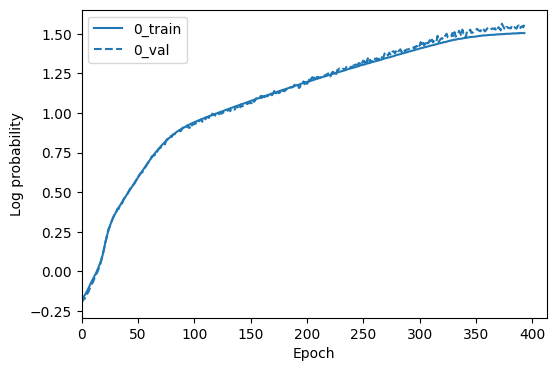

In [22]:
# plot train/validation loss
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
c = list(mcolors.TABLEAU_COLORS)
for i, m in enumerate(summaries):
    ax.plot(-1.0*np.array(m['training_loss']),
            ls='-', label=f"{i}_train", c=c[i])
    ax.plot(-1.0*np.array(m['validation_loss']),
            ls='--', label=f"{i}_val", c=c[i])
ax.set_xlim(0)
ax.set_xlabel('Epoch')
ax.set_ylabel('Log probability')
ax.legend()

1099it [00:00, 439003.82it/s]           


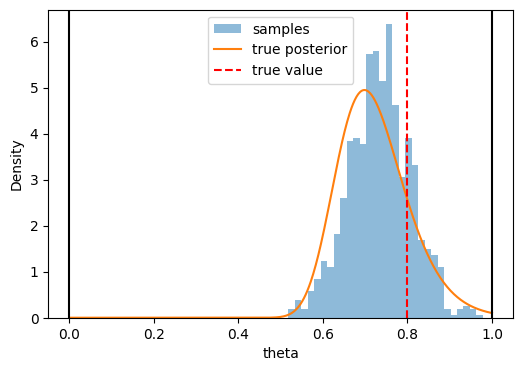

In [23]:
# choose a random input
seed_in = 49
np.random.seed(seed_in)
thetaobs = 0.8
xobs = [simulator([thetaobs])]
xobs = torch.Tensor(xobs)[:, None].to(device)

# generate samples from the posterior using accept/reject sampling
samples = posterior_ensemble.sample((1000,), xobs)
samples = samples.cpu().numpy()

# write down the true posterios


def pdf_yx(theta, x):
    c, d = 0.1, 0.01
    stdx = theta * c + d
    likelihood = (1.0 / np.sqrt(2 * np.pi * stdx**2)) * \
        np.exp(-0.5 * ((x - theta) / stdx)**2)
    # likelihood[(theta < 0) | (theta > 1)] = 0.0
    return likelihood


def Z_yx(x):
    # integrate pdf from 0 to 1
    t = np.linspace(0, 1, 10_000)
    return np.trapz(pdf_yx(t, x), t)


thetas = np.linspace(0, 1, 500)
px = np.array(pdf_yx(thetas, xobs.cpu().numpy())).flatten()
px /= Z_yx(xobs.cpu().numpy())


f, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.hist(samples, bins=30, density=True, alpha=0.5, label='samples')
ax.plot(thetas, px, label='true posterior')
ax.axvline(thetaobs, color='r', linestyle='--', label='true value')
ax.axvline(0, color='k', linestyle='-')
ax.axvline(1, color='k', linestyle='-')
ax.set_xlabel('theta')
ax.set_ylabel('Density')
ax.legend()

100%|██████████| 1000/1000 [00:02<00:00, 394.72it/s]
INFO:root:Mean logprob: 1.5358e+00Median logprob: 1.6462e+00
100%|██████████| 100/100 [00:12<00:00,  8.01it/s]
INFO:matplotlib.mathtext:Substituting symbol E from STIXNonUnicode


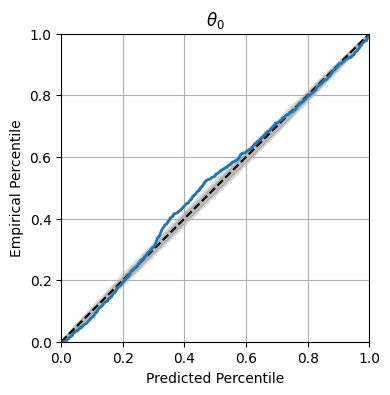

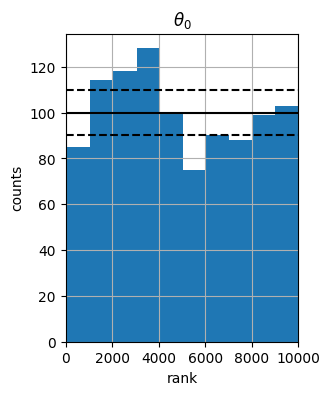

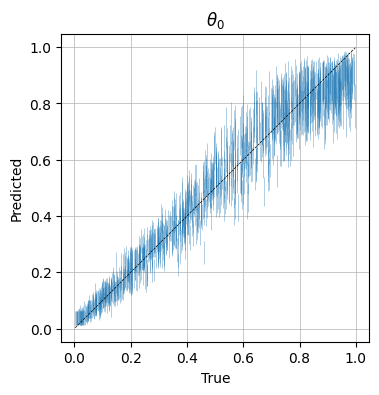

INFO:matplotlib.mathtext:Substituting symbol E from STIXNonUnicode


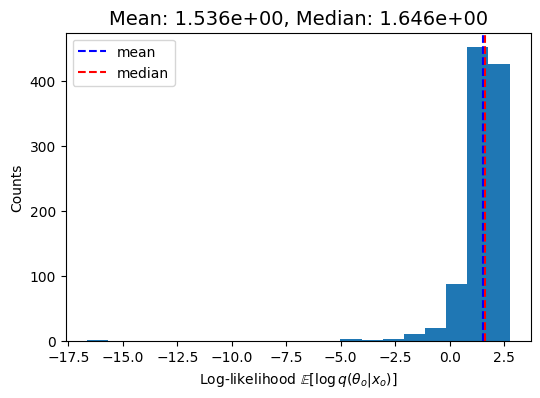

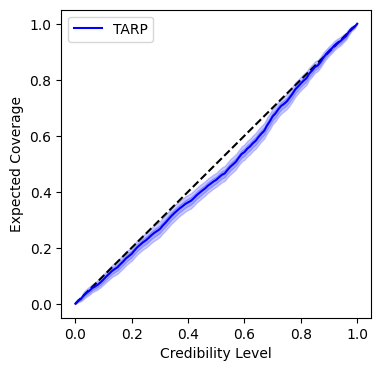

In [24]:
# Drawing samples from the ensemble posterior

metric = PosteriorCoverage(
    num_samples=10000, sample_method='direct',
    labels=[f'$\\theta_{i}$' for i in range(3)],
    plot_list=["coverage", "histogram", "predictions", "tarp", "logprob"],
    out_dir=None
)

fig = metric(
    posterior=posterior_ensemble,  # NeuralPosteriorEnsemble instance from sbi package
    x=x[::10], theta=theta[::10]
)

## Flow model

In [25]:
# define a prior
prior = ili.utils.Uniform(low=[0], high=[1], device=device)

# instantiate your neural networks to be used as an ensemble
nets = [
    ili.utils.load_nde_sbi(engine='NPE', model='nsf',
                           hidden_features=16, num_transforms=4)
]

# define training arguments
train_args = {
    'training_batch_size': 128,
    'learning_rate': 1e-4
}

# initialize the trainer
runner = InferenceRunner.load(
    backend='sbi',
    engine='NPE',
    prior=prior,
    nets=nets,
    device=device,
    train_args=train_args,
    proposal=None,
    out_dir=None
)

In [26]:
# train the model
posterior_ensemble, summaries = runner(loader=loader)

INFO:root:MODEL INFERENCE CLASS: NPE
INFO:root:Training model 1 / 1.


 Training neural network. Epochs trained: 131

INFO:root:It took 130.87460589408875 seconds to train models.


 Neural network successfully converged after 132 epochs.

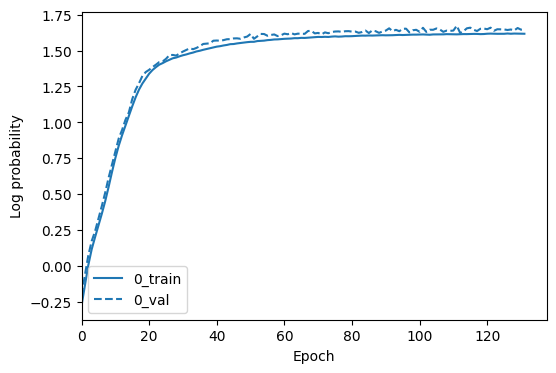

In [27]:
# plot train/validation loss
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
c = list(mcolors.TABLEAU_COLORS)
for i, m in enumerate(summaries):
    ax.plot(np.array(m['training_log_probs']),
            ls='-', label=f"{i}_train", c=c[i])
    ax.plot(np.array(m['validation_log_probs']),
            ls='--', label=f"{i}_val", c=c[i])
ax.set_xlim(0)
ax.set_xlabel('Epoch')
ax.set_ylabel('Log probability')
ax.legend()

100%|██████████| 1000/1000 [00:27<00:00, 36.77it/s]
INFO:root:Mean logprob: 1.6465e+00Median logprob: 1.6342e+00
100%|██████████| 100/100 [00:12<00:00,  8.28it/s]
INFO:matplotlib.mathtext:Substituting symbol E from STIXNonUnicode


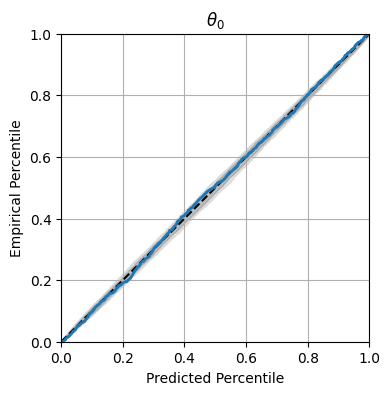

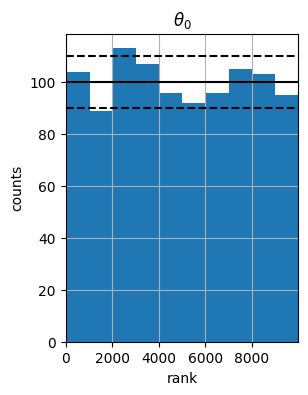

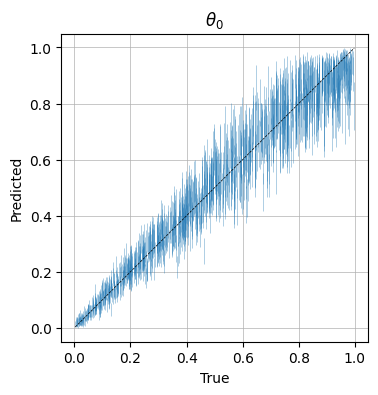

INFO:matplotlib.mathtext:Substituting symbol E from STIXNonUnicode


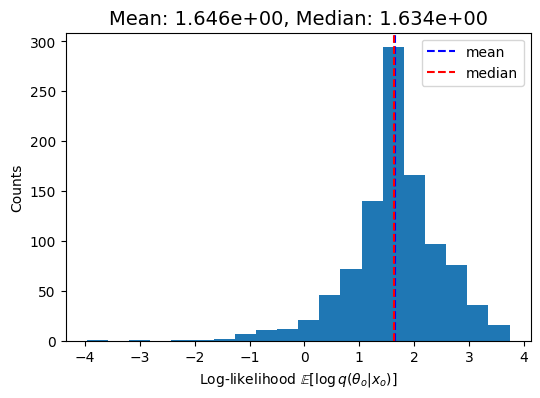

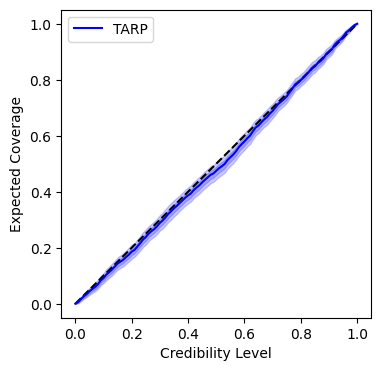

In [28]:
# Drawing samples from the ensemble posterior

metric = PosteriorCoverage(
    num_samples=10000, sample_method='direct',
    labels=[f'$\\theta_{i}$' for i in range(3)],
    plot_list=["coverage", "histogram", "predictions", "tarp", "logprob"],
    out_dir=None
)

fig = metric(
    posterior=posterior_ensemble,  # NeuralPosteriorEnsemble instance from sbi package
    x=x[::10], theta=theta[::10]
)

## Theory Model
For $\sigma_x(y) = c y + d$, we have that the posterior is given by:
$$ \begin{aligned}
p(y|x) &\propto p(x|y) p(y) \\
&\propto \frac{1}{\sqrt{2\pi\sigma_x(y)^2}} \exp\left[-\frac{(x - y)^2}{2 \sigma_x(y)^2}\right] \cdot \mathbb{I}_{[0, 1]}(y) \\
&\propto \frac{1}{\sqrt{2\pi(c y + d)}} \exp\left[-\frac{(x - y)^2}{2 (c y + d)^2}\right] \cdot \mathbb{I}_{[0, 1]}(y) \\
\end{aligned} $$


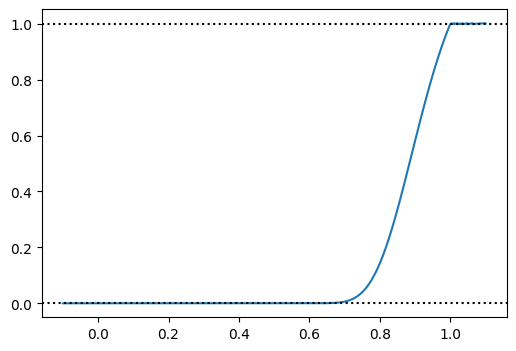

In [219]:
from scipy.interpolate import interp1d


def pdf_yx(theta, x):
    c, d = 0.1, 0.01
    stdx = theta * c + d
    likelihood = (1.0 / np.sqrt(2 * np.pi * stdx**2)) * \
        np.exp(-0.5 * ((x - theta) / stdx)**2)

    if isinstance(theta, np.ndarray):
        likelihood[(theta < 0) | (theta > 1)] = 0.0
    else:
        if (theta < 0) or (theta > 1):
            likelihood = 0.0
    return likelihood


def Z_yx(x):
    # integrate pdf from 0 to 1
    t = np.linspace(0, 1, 1000)
    return np.trapz(pdf_yx(t, x), t)


def cdf_yx(theta, x):
    # integrate pdf from 0 to theta
    t = np.linspace(0, theta, 1000)
    Z = Z_yx(x)
    return np.trapz(pdf_yx(t, x)/Z, t)


thetaobs = 0.8
xobs = simulator([thetaobs])


thetas = np.linspace(-0.1, 1.1, 1000)
cdf = [cdf_yx(t, xobs) for t in thetas]
invcdf = interp1d(cdf, thetas, bounds_error=False,
                  fill_value=(thetas[0], thetas[-1]))

f, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.plot(thetas, cdf, label='true posterior CDF')
ax.axhline(0, color='k', linestyle=':')
ax.axhline(1, color='k', linestyle=':')

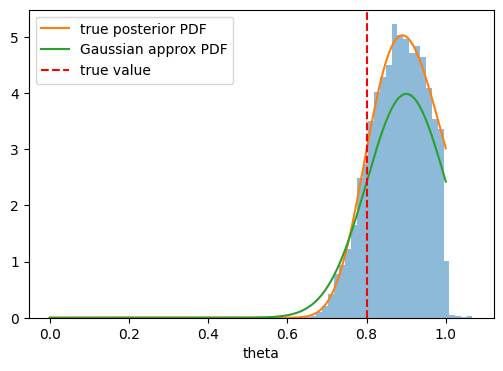

In [220]:
from scipy.stats import norm

samps = np.random.uniform(0, 1, size=10_000)
thetas_samp = invcdf(samps)
thetas = np.linspace(0, 1, 500)
pdf = np.array([pdf_yx(t, xobs) for t in thetas]) / Z_yx(xobs)

c, d = 0.1, 0.01
std_gauss = c * xobs + d
pdf_gauss = norm.pdf(thetas, loc=xobs, scale=std_gauss)


f, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.hist(thetas_samp, bins=30, density=True, alpha=0.5)
ax.plot(thetas, pdf, label='true posterior PDF')
ax.plot(thetas, pdf_gauss, label='Gaussian approx PDF')
ax.axvline(thetaobs, color='r', linestyle='--', label='true value')
ax.set_xlabel('theta')
ax.legend()

In [216]:
from tqdm import tqdm
Ntrials = 1000
Nsamps = 1_000

thetaobs = np.random.rand(Ntrials)
xobs = [simulator([to]) for to in thetaobs]
thetas_samp = np.zeros((Ntrials, Nsamps))
for i in tqdm(range(Ntrials)):
    invcdf = interp1d(
        [cdf_yx(t, xobs[i]) for t in np.linspace(0, 1, 500)],
        np.linspace(0, 1, 500),
        bounds_error=False, fill_value=(0, 1)
    )
    thetas_samp[i, :] = invcdf(np.random.uniform(0, 1, size=Nsamps))

100%|██████████| 1000/1000 [00:58<00:00, 17.05it/s]


[Text(0.5, 0, 'True'), Text(0, 0.5, 'Predicted')]

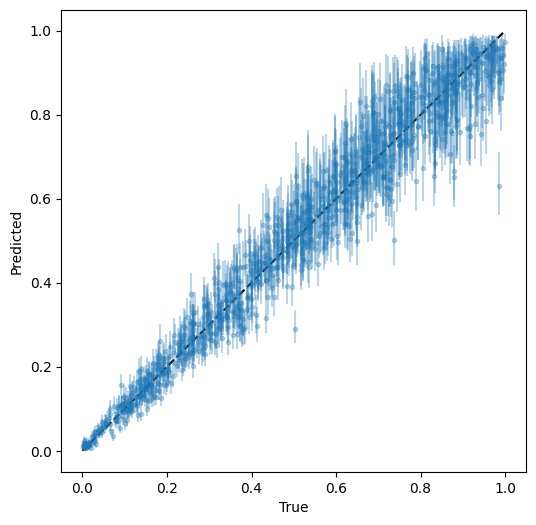

In [217]:
f, ax = plt.subplots(1, 1, figsize=(6, 6))
# Calculate percentiles once for efficiency
lower, median, upper = np.percentile(thetas_samp, [16, 50, 84], axis=1)

ax.plot([0, 1], [0, 1], 'k--', label='y=x')
ax.errorbar(
    thetaobs,
    median,
    yerr=[median - lower, upper - median],
    fmt='.', alpha=0.3
)
ax.set(xlabel='True', ylabel='Predicted')

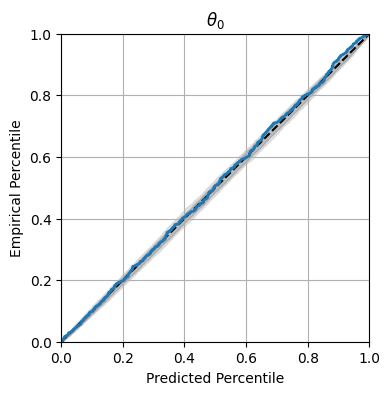

In [ ]:
metric = PosteriorCoverage(
    num_samples=10000, sample_method='direct',
    labels=[f'$\\theta_{i}$' for i in range(3)],
    plot_list=["coverage", "histogram", "predictions", "tarp", "logprob"],
    out_dir=None
)

ranks = metric._plot_coverage(thetas_samp[:, None], thetaobs[:, None], ['hi'])